In [1]:
# ======================================
# 03 Model Training + Signal Validation
# ======================================
#
# Purpose:
# --------
# This notebook trains the long-horizon stock selection model.
#
# Notebook 03 is responsible for:
#   1. Loading prices + engineered features
#   2. Creating 3-year forward excess-return labels
#   3. Training a LightGBM regression model
#   4. Calibrating predictions using validation data only
#   5. Validating signal quality using prediction buckets
#   6. Exporting scored test predictions for notebook 04
#
# Notebook 04 then handles portfolio construction and cohort backtesting.

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import lightgbm as lgb
import joblib

from sklearn.isotonic import IsotonicRegression

# ---- Paths ----
PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"
MODEL_DIR = PROJECT_ROOT / "models"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

PRICE_FILE = RAW_DIR / "prices.parquet"
FEATURE_FILE = PROCESSED_DIR / "features_v3.parquet"

# ---- Output files ----
SCORED_TEST_FILE = PROCESSED_DIR / "scored_test_v4.parquet"
BUCKET_STATS_FILE = PROCESSED_DIR / "bucket_stats_v4.csv"
SIGNAL_SUMMARY_FILE = PROCESSED_DIR / "signal_summary_v4.csv"

MODEL_FILE = MODEL_DIR / "lightgbm_v4.joblib"
ISO_FILE = MODEL_DIR / "isotonic_calibrator_v4.joblib"
FEATURE_COLS_FILE = MODEL_DIR / "feature_cols_v4.joblib"

print("Project root:", PROJECT_ROOT)

Project root: /Users/neilyejjey/stock_signal_engine_v1


In [2]:
# ======================================
# Load Prices + Engineered Features
# ======================================
#
# prices:
#   Raw adjusted price history.
#
# features:
#   Feature table created by the feature engineering notebooks.
#   This should include raw features, cross-sectional rank features,
#   composite features, and sector metadata.

prices = pd.read_parquet(PRICE_FILE)
features = pd.read_parquet(FEATURE_FILE)

# ---- Date handling ----
prices["date"] = pd.to_datetime(prices["date"])
features["date"] = pd.to_datetime(features["date"])

# ---- Sorting ----
prices = prices.sort_values(["ticker", "date"]).reset_index(drop=True)
features = features.sort_values(["ticker", "date"]).reset_index(drop=True)

print("Prices shape:", prices.shape)
print("Features shape:", features.shape)

print("\nFeature columns:")
print(features.columns.tolist())

features.head()

Prices shape: (1903828, 8)
Features shape: (1903828, 17)

Feature columns:
['date', 'ticker', 'ret_6m', 'ret_12m', 'vol_12m', 'drawdown', 'pe_ratio', 'earnings_yield', 'ret_6m_rank', 'ret_12m_rank', 'vol_12m_rank', 'drawdown_rank', 'low_vol_rank', 'momentum_vol_adj', 'momentum_composite', 'quality_value_combo', 'sector']


,date,ticker,ret_6m,ret_12m,vol_12m,drawdown,pe_ratio,earnings_yield,ret_6m_rank,ret_12m_rank,vol_12m_rank,drawdown_rank,low_vol_rank,momentum_vol_adj,momentum_composite,quality_value_combo,sector
0,2010-01-04,A,NaN,NaN,NaN,0.000000,26.902868,0.037171,0.5,0.5,0.5,0.501182,0.5,0.0,NaN,NaN,Healthcare
1,2010-01-05,A,NaN,NaN,NaN,-0.010863,26.902868,0.037171,0.5,0.5,0.5,0.193396,0.5,0.0,NaN,NaN,Healthcare
2,2010-01-06,A,NaN,NaN,NaN,-0.014377,26.902868,0.037171,0.5,0.5,0.5,0.212264,0.5,0.0,NaN,NaN,Healthcare
3,2010-01-07,A,NaN,NaN,NaN,-0.015655,26.902868,0.037171,0.5,0.5,0.5,0.252358,0.5,0.0,NaN,NaN,Healthcare
4,2010-01-08,A,NaN,NaN,NaN,-0.015974,26.902868,0.037171,0.5,0.5,0.5,0.306604,0.5,0.0,NaN,NaN,Healthcare


In [3]:
# ======================================
# Download / Build Benchmark Series
# ======================================
#
# Benchmark:
#   SPY is used as the market benchmark.
#
# The target is not absolute stock return.
# The target is stock return in excess of SPY over the same forward window.

import yfinance as yf

BENCHMARK_TICKER = "SPY"

START_DATE = prices["date"].min().strftime("%Y-%m-%d")
END_DATE = (prices["date"].max() + pd.Timedelta(days=1)).strftime("%Y-%m-%d")

benchmark = yf.download(
    BENCHMARK_TICKER,
    start=START_DATE,
    end=END_DATE,
    auto_adjust=False,
    progress=False,
    threads=False,
)

# yfinance sometimes returns MultiIndex columns
benchmark.columns = [
    col[0] if isinstance(col, tuple) else col
    for col in benchmark.columns
]

benchmark = benchmark.reset_index().rename(columns={
    "Date": "date",
    "Adj Close": "benchmark_adj_close",
})

benchmark["date"] = pd.to_datetime(benchmark["date"])

benchmark = benchmark[
    ["date", "benchmark_adj_close"]
].sort_values("date").reset_index(drop=True)

print("Benchmark shape:", benchmark.shape)
benchmark.head()

Benchmark shape: (4024, 2)


,date,benchmark_adj_close
0,2010-01-04,84.796364
1,2010-01-05,85.020828
2,2010-01-06,85.080696
3,2010-01-07,85.439850
4,2010-01-08,85.724197


In [4]:
# ======================================
# Create Forward 3-Year Stock + Benchmark Returns
# ======================================
#
# FORWARD_DAYS:
#   Approximate number of trading days in 3 years.
#
# For each stock/date:
#   fwd_3y_stock_return = future stock price / current stock price - 1
#
# For benchmark/date:
#   fwd_3y_benchmark_return = future SPY price / current SPY price - 1

FORWARD_DAYS = 252 * 3  # ~3 trading years

# ---- Stock forward returns ----
prices = prices.copy()

prices["fwd_3y_stock_return"] = (
    prices.groupby("ticker")["adj_close"].shift(-FORWARD_DAYS)
    / prices["adj_close"]
    - 1
)

stock_forward_returns = prices[
    ["date", "ticker", "fwd_3y_stock_return"]
].copy()

# ---- Benchmark forward returns ----
benchmark = benchmark.copy()

benchmark["fwd_3y_benchmark_return"] = (
    benchmark["benchmark_adj_close"].shift(-FORWARD_DAYS)
    / benchmark["benchmark_adj_close"]
    - 1
)

benchmark_forward_returns = benchmark[
    ["date", "fwd_3y_benchmark_return"]
].copy()

print("Stock forward returns:", stock_forward_returns.shape)
print("Benchmark forward returns:", benchmark_forward_returns.shape)

stock_forward_returns.head()

Stock forward returns: (1903828, 3)
Benchmark forward returns: (4024, 2)


,date,ticker,fwd_3y_stock_return
0,2010-01-04,A,0.383023
1,2010-01-05,A,0.388098
2,2010-01-06,A,0.381916
3,2010-01-07,A,0.421081
4,2010-01-08,A,0.432034


In [5]:
# ======================================
# Build Forward Excess-Return Labels
# ======================================
#
# This creates the model target:
#
#   excess_fwd_3y_return = stock 3Y return - SPY 3Y return
#
# This makes the model a cross-sectional stock selection engine:
#   "Which stocks are likely to beat SPY over the next ~3 years?"

labels = stock_forward_returns.merge(
    benchmark_forward_returns,
    on="date",
    how="left",
)

labels["excess_fwd_3y_return"] = (
    labels["fwd_3y_stock_return"]
    - labels["fwd_3y_benchmark_return"]
)

# Legacy binary label retained for diagnostics only.
# The model itself uses regression.
labels["label"] = (labels["excess_fwd_3y_return"] > 0.25).astype(int)

print(
    labels[
        [
            "fwd_3y_stock_return",
            "fwd_3y_benchmark_return",
            "excess_fwd_3y_return",
            "label",
        ]
    ].describe()
)

labels.head()

       fwd_3y_stock_return  fwd_3y_benchmark_return  excess_fwd_3y_return  \
count         1.525710e+06             1.525711e+06          1.525710e+06   
mean          6.339164e-01             4.748809e-01          1.590358e-01   
std           1.030639e+00             1.548953e-01          1.015065e+00   
min          -9.622105e-01             1.119535e-02         -1.750727e+00   
25%           1.719980e-01             3.524691e-01         -2.828699e-01   
50%           4.839141e-01             4.479890e-01          1.817831e-02   
75%           8.635639e-01             5.787042e-01          3.798510e-01   
max           1.179765e+02             1.112218e+00          1.171696e+02   

              label  
count  1.903828e+06  
mean   2.595250e-01  
std    4.383741e-01  
min    0.000000e+00  
25%    0.000000e+00  
50%    0.000000e+00  
75%    1.000000e+00  
max    1.000000e+00  


,date,ticker,fwd_3y_stock_return,fwd_3y_benchmark_return,excess_fwd_3y_return,label
0,2010-01-04,A,0.383023,0.374334,0.008689,0
1,2010-01-05,A,0.388098,0.366960,0.021138,0
2,2010-01-06,A,0.381916,0.362068,0.019848,0
3,2010-01-07,A,0.421081,0.359790,0.061291,0
4,2010-01-08,A,0.432034,0.366053,0.065981,0


In [6]:
# ======================================
# Build Modeling Table
# ======================================
#
# Merge engineered features with future labels.
#
# Important:
#   Future returns are only used as training labels.
#   They are not used as input features.

model_df = features.merge(
    labels[
        [
            "date",
            "ticker",
            "fwd_3y_stock_return",
            "fwd_3y_benchmark_return",
            "excess_fwd_3y_return",
            "label",
        ]
    ],
    on=["date", "ticker"],
    how="left",
)

print("Model DF shape:", model_df.shape)
model_df.head()

Model DF shape: (1903828, 21)


,date,ticker,ret_6m,ret_12m,vol_12m,drawdown,pe_ratio,earnings_yield,ret_6m_rank,ret_12m_rank,...,drawdown_rank,low_vol_rank,momentum_vol_adj,momentum_composite,quality_value_combo,sector,fwd_3y_stock_return,fwd_3y_benchmark_return,excess_fwd_3y_return,label
0,2010-01-04,A,NaN,NaN,NaN,0.000000,26.902868,0.037171,0.5,0.5,...,0.501182,0.5,0.0,NaN,NaN,Healthcare,0.383023,0.374334,0.008689,0
1,2010-01-05,A,NaN,NaN,NaN,-0.010863,26.902868,0.037171,0.5,0.5,...,0.193396,0.5,0.0,NaN,NaN,Healthcare,0.388098,0.366960,0.021138,0
2,2010-01-06,A,NaN,NaN,NaN,-0.014377,26.902868,0.037171,0.5,0.5,...,0.212264,0.5,0.0,NaN,NaN,Healthcare,0.381916,0.362068,0.019848,0
3,2010-01-07,A,NaN,NaN,NaN,-0.015655,26.902868,0.037171,0.5,0.5,...,0.252358,0.5,0.0,NaN,NaN,Healthcare,0.421081,0.359790,0.061291,0
4,2010-01-08,A,NaN,NaN,NaN,-0.015974,26.902868,0.037171,0.5,0.5,...,0.306604,0.5,0.0,NaN,NaN,Healthcare,0.432034,0.366053,0.065981,0


In [7]:
# ======================================
# Define Feature Set
# ======================================
#
# V1 features:
#   Basic momentum/risk features.
#
# V2 features:
#   Fundamental valuation features.
#
# V3 features:
#   Cross-sectional rank and composite features.
#
# Sector is kept in the dataset for diagnostics, but not used as a model feature.

feature_cols = [
    # V1
    "ret_6m",
    "ret_12m",
    "vol_12m",
    "drawdown",

    # V2
    "pe_ratio",
    "earnings_yield",

    # V3
    "ret_6m_rank",
    "ret_12m_rank",
    "vol_12m_rank",
    "drawdown_rank",
    "momentum_vol_adj",
    "quality_value_combo",
]

target_raw_col = "excess_fwd_3y_return"
target_col = "target"

missing_features = [c for c in feature_cols if c not in model_df.columns]

if missing_features:
    raise ValueError(f"Missing expected feature columns: {missing_features}")

print("Feature columns:")
feature_cols

Feature columns:


['ret_6m',
 'ret_12m',
 'vol_12m',
 'drawdown',
 'pe_ratio',
 'earnings_yield',
 'ret_6m_rank',
 'ret_12m_rank',
 'vol_12m_rank',
 'drawdown_rank',
 'momentum_vol_adj',
 'quality_value_combo']

In [8]:
# ======================================
# Clean Modeling Table + Transform Target
# ======================================
#
# We train the model on a symmetric log transform of excess returns:
#
#   target = sign(x) * log1p(abs(x))
#
# Why:
#   Long-horizon equity returns are heavy-tailed.
#   The transform reduces outlier dominance while preserving direction.
#
# Important:
#   Because the model predicts this transformed target,
#   predictions must later be inverse-transformed using expm1.

model_df = model_df.replace([np.inf, -np.inf], np.nan)

model_df = model_df.dropna(
    subset=feature_cols + [target_raw_col]
).reset_index(drop=True)

model_df[target_col] = (
    np.sign(model_df[target_raw_col])
    * np.log1p(np.abs(model_df[target_raw_col]))
)

print("Clean model DF shape:", model_df.shape)

print("\nFeature nulls:")
print(model_df[feature_cols].isnull().sum())

print("\nTarget summary:")
print(model_df[[target_raw_col, target_col]].describe())

model_df[feature_cols + ["sector", target_raw_col, target_col]].head()

Clean model DF shape: (1326140, 22)

Feature nulls:
ret_6m                 0
ret_12m                0
vol_12m                0
drawdown               0
pe_ratio               0
earnings_yield         0
ret_6m_rank            0
ret_12m_rank           0
vol_12m_rank           0
drawdown_rank          0
momentum_vol_adj       0
quality_value_combo    0
dtype: int64

Target summary:
       excess_fwd_3y_return        target
count          1.326140e+06  1.326140e+06
mean           1.576046e-01  7.065492e-02
std            1.021690e+00  4.450149e-01
min           -1.628888e+00 -9.665611e-01
25%           -2.799416e-01 -2.468145e-01
50%            1.755135e-02  1.739910e-02
75%            3.769820e-01  3.198941e-01
max            1.171696e+02  4.772121e+00


,ret_6m,ret_12m,vol_12m,drawdown,pe_ratio,earnings_yield,ret_6m_rank,ret_12m_rank,vol_12m_rank,drawdown_rank,momentum_vol_adj,quality_value_combo,sector,excess_fwd_3y_return,target
0,0.509190,0.338019,0.019335,-0.000955,26.902868,0.037171,0.862150,0.699764,0.638298,0.780600,17.481356,0.805120,Healthcare,-0.148162,-0.138163
1,0.452223,0.340116,0.019331,-0.010258,26.902868,0.037171,0.871495,0.724057,0.636792,0.787529,17.593151,0.806626,Healthcare,-0.125504,-0.118231
2,0.437001,0.341977,0.019330,-0.012405,26.902868,0.037171,0.866822,0.733491,0.636792,0.713626,17.690515,0.806626,Healthcare,-0.091641,-0.087682
3,0.447818,0.346316,0.019329,-0.010497,26.902868,0.037171,0.885514,0.742925,0.641509,0.773672,17.915599,0.801909,Healthcare,-0.097932,-0.093429
4,0.475887,0.351298,0.019330,-0.007157,26.902868,0.037171,0.894860,0.757075,0.641509,0.849885,18.173225,0.801909,Healthcare,-0.097222,-0.092781


In [9]:
# ======================================
# Downsample to Monthly Observations
# ======================================
#
# Why:
#   Daily rows with 3-year forward labels heavily overlap.
#   That creates high autocorrelation and can make performance look cleaner
#   than it really is.
#
# Approach:
#   For each ticker/month, keep the final available trading day.
#
# This preserves the long-horizon thesis while reducing duplicate signal windows.

model_df["year_month"] = model_df["date"].dt.to_period("M")

model_df_monthly = (
    model_df.sort_values("date")
    .groupby(["ticker", "year_month"])
    .tail(1)
    .reset_index(drop=True)
)

print("Daily shape:  ", model_df.shape)
print("Monthly shape:", model_df_monthly.shape)

model_df_monthly.head()

Daily shape:   (1326140, 23)
Monthly shape: (63348, 23)


,date,ticker,ret_6m,ret_12m,vol_12m,drawdown,pe_ratio,earnings_yield,ret_6m_rank,ret_12m_rank,...,momentum_vol_adj,momentum_composite,quality_value_combo,sector,fwd_3y_stock_return,fwd_3y_benchmark_return,excess_fwd_3y_return,label,target,year_month
0,2011-01-31,KDP,-0.047424,0.306040,0.016876,-0.104198,17.339870,0.057671,0.046620,0.577830,...,18.133767,0.312225,1.318189,Consumer Defensive,0.468167,0.441076,0.027091,0,0.026730,2011-01
1,2011-01-31,DRI,0.129701,0.280426,0.016387,-0.059313,21.187567,0.047197,0.414918,0.528302,...,17.111186,0.471610,1.247331,Consumer Cyclical,0.127669,0.441076,-0.313407,0,-0.272625,2011-01
2,2011-01-31,HSY,0.017207,0.305204,0.012225,-0.089241,44.487300,0.022478,0.128205,0.575472,...,24.964260,0.351838,0.985217,Consumer Defensive,1.246273,0.441076,0.805197,1,0.590670,2011-01
3,2011-01-31,FIX,0.092513,0.093038,0.023145,-0.108482,57.149240,0.017498,0.312354,0.219340,...,4.019692,0.265847,0.264598,Industrials,0.358457,0.441076,-0.082619,0,-0.079383,2011-01
4,2011-01-31,A,0.451422,0.435976,0.019251,-0.056821,26.902868,0.037171,0.941725,0.745283,...,22.646128,0.843504,0.780682,Healthcare,0.369731,0.441076,-0.071345,0,-0.068915,2011-01


In [10]:
# ======================================
# Time-Based Train / Validation / Test Split
# ======================================
#
# Train:
#   Used to fit LightGBM.
#
# Validation:
#   Used for early stopping and isotonic calibration.
#
# Test:
#   Blind out-of-sample evaluation.
#
# Important:
#   The isotonic calibrator is fit only on validation data.
#   Test data is never used to fit either the model or calibrator.

train_end = pd.Timestamp("2017-12-31")
valid_end = pd.Timestamp("2020-12-31")

df = model_df_monthly.copy()

train_df = df[df["date"] <= train_end].copy()
valid_df = df[(df["date"] > train_end) & (df["date"] <= valid_end)].copy()
test_df = df[df["date"] > valid_end].copy()

X_train = train_df[feature_cols]
y_train = train_df[target_col]

X_valid = valid_df[feature_cols]
y_valid = valid_df[target_col]

X_test = test_df[feature_cols]
y_test = test_df[target_col]

print("Train:", X_train.shape, y_train.shape)
print("Valid:", X_valid.shape, y_valid.shape)
print("Test :", X_test.shape, y_test.shape)

print("\nDate ranges:")
print("Train:", train_df["date"].min(), "to", train_df["date"].max())
print("Valid:", valid_df["date"].min(), "to", valid_df["date"].max())
print("Test :", test_df["date"].min(), "to", test_df["date"].max())

Train: (35926, 12) (35926,)
Valid: (16309, 12) (16309,)
Test : (11113, 12) (11113,)

Date ranges:
Train: 2011-01-31 00:00:00 to 2017-12-29 00:00:00
Valid: 2018-01-31 00:00:00 to 2020-12-31 00:00:00
Test : 2021-01-29 00:00:00 to 2022-12-23 00:00:00


In [11]:
# ======================================
# Train LightGBM Regressor
# ======================================
#
# Objective:
#   Predict transformed 3-year excess return.
#
# Notes:
#   - Early stopping uses validation set.
#   - The model is optimized for signal generation/ranking, not direct trading.
#   - Calibration happens after training.

model = lgb.LGBMRegressor(
    objective="regression",
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=31,
    min_child_samples=100,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=1.0,
    reg_lambda=1.0,
    random_state=42,
)

model.fit(
    X_train,
    y_train,
    eval_set=[(X_valid, y_valid)],
    eval_metric="l2",
    callbacks=[
        lgb.early_stopping(50),
        lgb.log_evaluation(50),
    ],
)

model

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000564 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3051
[LightGBM] [Info] Number of data points in the train set: 35926, number of used features: 12
[LightGBM] [Info] Start training from score 0.104792
Training until validation scores don't improve for 50 rounds
[50]	valid_0's l2: 0.191718
[100]	valid_0's l2: 0.192483
Early stopping, best iteration is:
[50]	valid_0's l2: 0.191718


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.03
,n_estimators,500
,subsample_for_bin,200000
,objective,'regression'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,100


In [12]:
# ======================================
# Score Validation + Test Sets
# ======================================
#
# The model predicts transformed target values.
#
# We convert predictions back to raw return space using:
#
#   raw_pred = sign(pred) * expm1(abs(pred))
#
# This is the inverse of the symmetric log target transform.

def inverse_symmetric_log(x):
    return np.sign(x) * np.expm1(np.abs(x))


valid_df = valid_df.copy()
test_df = test_df.copy()

# ---- Raw model predictions in transformed target space ----
valid_preds = model.predict(X_valid)
test_preds = model.predict(X_test)

valid_df["predicted_target"] = valid_preds
test_df["predicted_target"] = test_preds

# ---- Convert back to raw return space ----
valid_df["predicted_excess_return"] = inverse_symmetric_log(valid_preds)
test_df["predicted_excess_return"] = inverse_symmetric_log(test_preds)

print("Raw validation correlation:")
print(valid_df["predicted_excess_return"].corr(valid_df[target_raw_col]))

print("\nRaw test correlation:")
print(test_df["predicted_excess_return"].corr(test_df[target_raw_col]))

test_df[
    ["date", "ticker", target_raw_col, "predicted_target", "predicted_excess_return"]
].head()

Raw validation correlation:
0.36706878629952655

Raw test correlation:
0.1793574965817429


,date,ticker,excess_fwd_3y_return,predicted_target,predicted_excess_return
52235,2021-01-29,ORLY,1.066515,0.204169,0.226505
52236,2021-01-29,CRM,-0.123752,0.222770,0.249534
52237,2021-01-29,HII,0.441008,0.099641,0.104774
52238,2021-01-29,LEN,0.549986,0.125100,0.133262
52239,2021-01-29,PPG,-0.275842,0.130384,0.139265


In [13]:
# ======================================
# Fit Isotonic Calibration on Validation Set
# ======================================
#
# Why:
#   Tree models can be good rankers but poor magnitude estimators.
#   Isotonic Regression learns a monotonic mapping from predicted values
#   to realized excess returns.
#
# Critical anti-leakage rule:
#   Fit isotonic regression on validation data only.
#   Apply it to test data afterward.

iso = IsotonicRegression(out_of_bounds="clip")

iso.fit(
    valid_df["predicted_excess_return"],
    valid_df[target_raw_col],
)

valid_df["calibrated_pred"] = iso.transform(
    valid_df["predicted_excess_return"]
)

test_df["calibrated_pred"] = iso.transform(
    test_df["predicted_excess_return"]
)

print("Validation correlations:")
print("Raw:       ", valid_df["predicted_excess_return"].corr(valid_df[target_raw_col]))
print("Calibrated:", valid_df["calibrated_pred"].corr(valid_df[target_raw_col]))

print("\nTest correlations:")
print("Raw:       ", test_df["predicted_excess_return"].corr(test_df[target_raw_col]))
print("Calibrated:", test_df["calibrated_pred"].corr(test_df[target_raw_col]))

test_df[
    ["date", "ticker", target_raw_col, "predicted_excess_return", "calibrated_pred"]
].head()

Validation correlations:
Raw:        0.36706878629952655
Calibrated: 0.41334873346453666

Test correlations:
Raw:        0.1793574965817429
Calibrated: 0.16612253571309982


,date,ticker,excess_fwd_3y_return,predicted_excess_return,calibrated_pred
52235,2021-01-29,ORLY,1.066515,0.226505,0.275222
52236,2021-01-29,CRM,-0.123752,0.249534,0.458290
52237,2021-01-29,HII,0.441008,0.104774,0.087501
52238,2021-01-29,LEN,0.549986,0.133262,0.087501
52239,2021-01-29,PPG,-0.275842,0.139265,0.087501


In [14]:
# ======================================
# Prediction Diagnostics
# ======================================
#
# delta:
#   calibrated prediction - realized excess return
#
# Positive delta:
#   Model overpredicted.
#
# Negative delta:
#   Model underpredicted.
#
# This is mainly diagnostic; portfolio construction uses rankings.

test_df["delta"] = test_df["calibrated_pred"] - test_df[target_raw_col]

print("Prediction error summary:")
print(test_df["delta"].describe())

print("\nPrediction summaries:")
print(
    test_df[
        ["predicted_excess_return", "calibrated_pred", target_raw_col]
    ].describe()
)

Prediction error summary:
count    11113.000000
mean         0.021751
std          1.892101
min       -101.759408
25%         -0.211268
50%          0.192240
75%          0.535803
max          4.345397
Name: delta, dtype: float64

Prediction summaries:
       predicted_excess_return  calibrated_pred  excess_fwd_3y_return
count             11113.000000     11113.000000          11113.000000
mean                  0.140483         0.136462              0.114711
std                   0.124241         0.412536              1.916384
min                  -0.164749        -0.331281             -1.538221
25%                   0.064796        -0.036962             -0.446058
50%                   0.116785         0.087501             -0.141139
75%                   0.186131         0.143341              0.262564
max                   1.077473         3.658490            102.349811


In [15]:
# ======================================
# Bucket Signal Validation
# ======================================
#
# We rank test predictions and split them into quintiles.
#
# This asks:
#   Do higher predicted buckets actually produce higher realized excess returns?
#
# This is signal validation, not portfolio backtesting.
# Notebook 04 handles portfolio strategy analysis.

test_df["pred_rank"] = test_df["calibrated_pred"].rank(method="first")

test_df["pred_bucket"] = pd.qcut(
    test_df["pred_rank"],
    q=5,
    labels=False,
)

bucket_stats = test_df.groupby("pred_bucket").agg({
    "calibrated_pred": "mean",
    target_raw_col: "mean",
    "delta": ["mean", "std", "count"],
})

bucket_stats.columns = [
    "pred_mean",
    "actual_mean",
    "delta_mean",
    "delta_std",
    "count",
]

bucket_stats = bucket_stats.sort_index()

bucket_stats

,pred_mean,actual_mean,delta_mean,delta_std,count
pred_bucket,,,,,
0,-0.159970,-0.112502,-0.047467,0.544618,2223
1,-0.040018,-0.082346,0.042328,0.587501,2222
2,0.076601,0.012219,0.064381,0.630283,2223
3,0.130961,0.061416,0.069545,1.256793,2222
4,0.674656,0.694656,-0.020000,3.908288,2223


In [16]:
# ======================================
# Signal Strength Metrics
# ======================================
#
# Top-bottom spread:
#   Difference between realized excess return in top and bottom prediction buckets.
#
# Top bucket positive rate:
#   Share of top-bucket stocks that beat SPY over the 3-year horizon.

spread = (
    bucket_stats["actual_mean"].iloc[-1]
    - bucket_stats["actual_mean"].iloc[0]
)

top_bucket = test_df[test_df["pred_bucket"] == test_df["pred_bucket"].max()]
hit_rate_top = (top_bucket[target_raw_col] > 0).mean()

is_monotonic = bucket_stats["actual_mean"].is_monotonic_increasing

signal_summary = pd.DataFrame([
    {
        "top_bottom_spread": spread,
        "top_bucket_positive_rate": hit_rate_top,
        "bucket_actuals_monotonic": is_monotonic,
        "raw_test_corr": test_df["predicted_excess_return"].corr(test_df[target_raw_col]),
        "calibrated_test_corr": test_df["calibrated_pred"].corr(test_df[target_raw_col]),
    }
])

print("Top-Bottom Spread:", spread)
print("Top Bucket Positive Rate:", hit_rate_top)
print("Actual bucket means monotonic:", is_monotonic)

signal_summary

Top-Bottom Spread: 0.8071583626946879
Top Bucket Positive Rate: 0.4709851551956815
Actual bucket means monotonic: True


,top_bottom_spread,top_bucket_positive_rate,bucket_actuals_monotonic,raw_test_corr,calibrated_test_corr
0,0.807158,0.470985,True,0.179357,0.166123


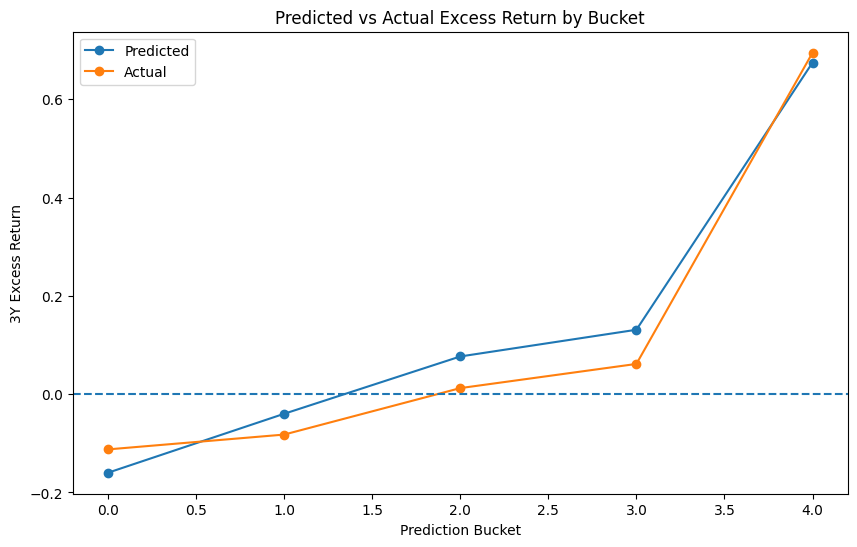

In [17]:
# ======================================
# Bucket Plot: Predicted vs Actual
# ======================================
#
# Visual check:
#   The actual line should generally increase across prediction buckets.
#
# If actual returns are monotonic across buckets,
# the model is ranking stocks in a useful direction.

plt.figure(figsize=(10, 6))

plt.plot(
    bucket_stats.index,
    bucket_stats["pred_mean"],
    marker="o",
    label="Predicted",
)

plt.plot(
    bucket_stats.index,
    bucket_stats["actual_mean"],
    marker="o",
    label="Actual",
)

plt.axhline(0, linestyle="--")
plt.xlabel("Prediction Bucket")
plt.ylabel("3Y Excess Return")
plt.title("Predicted vs Actual Excess Return by Bucket")
plt.legend()
plt.show()

In [18]:
# ======================================
# Feature Importance
# ======================================
#
# LightGBM feature importance is used as a sanity check:
#
#   - Is the model relying on sensible features?
#   - Is one engineered feature dominating too heavily?
#
# This is not a complete interpretability analysis.
# Future work can add permutation importance or SHAP.

feature_importance = pd.DataFrame({
    "feature": feature_cols,
    "importance": model.feature_importances_,
})

feature_importance = feature_importance.sort_values(
    "importance",
    ascending=False,
).reset_index(drop=True)

feature_importance

,feature,importance
0,pe_ratio,677
1,earnings_yield,196
2,quality_value_combo,147
3,vol_12m,129
4,vol_12m_rank,104
5,drawdown_rank,71
6,drawdown,65
7,ret_12m_rank,51
8,momentum_vol_adj,20
9,ret_6m,18


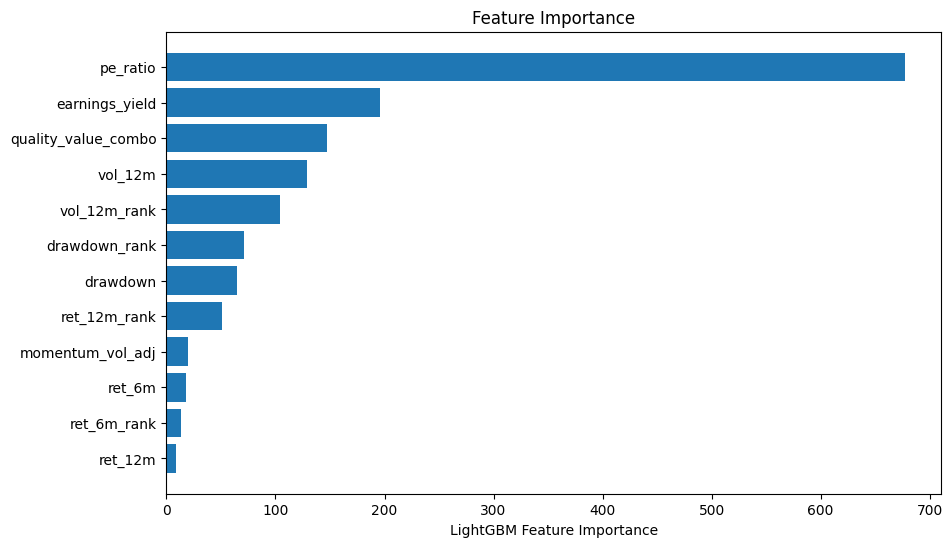

In [19]:
# ======================================
# Feature Importance Plot
# ======================================

plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["feature"][::-1],
    feature_importance["importance"][::-1],
)

plt.xlabel("LightGBM Feature Importance")
plt.title("Feature Importance")
plt.show()

In [20]:
# ======================================
# Optional Quick Top-K Sanity Check
# ======================================
#
# This is not the official strategy backtest.
# It is only a lightweight sanity check before exporting scored signals.
#
# Official portfolio/cohort analysis lives in notebook 04.

def quick_topk_summary(df, top_k=20, score_col="calibrated_pred"):
    portfolio = []

    for date, group in df.groupby("date"):
        group = group.dropna(subset=[score_col]).copy()

        if group.empty:
            continue

        subset = group.nlargest(min(top_k, len(group)), score_col).copy()

        ranks = subset[score_col].rank(method="first")
        weights = ranks / ranks.sum()

        subset["weight"] = weights
        portfolio.append(subset)

    portfolio = pd.concat(portfolio, ignore_index=True)

    cohort_returns = (
        portfolio
        .assign(weighted_excess=portfolio[target_raw_col] * portfolio["weight"])
        .groupby("date")
        .agg(
            excess_return=("weighted_excess", "sum"),
            benchmark_return=("fwd_3y_benchmark_return", "first"),
            num_positions=("ticker", "count"),
        )
        .reset_index()
    )

    return {
        "top_k": top_k,
        "mean_excess_return": cohort_returns["excess_return"].mean(),
        "median_excess_return": cohort_returns["excess_return"].median(),
        "excess_std": cohort_returns["excess_return"].std(),
        "hit_rate": (cohort_returns["excess_return"] > 0).mean(),
    }


quick_summary = pd.DataFrame([
    quick_topk_summary(test_df, top_k=3),
    quick_topk_summary(test_df, top_k=5),
    quick_topk_summary(test_df, top_k=20),
])

quick_summary

,top_k,mean_excess_return,median_excess_return,excess_std,hit_rate
0,3,1.609875,0.828377,2.969783,0.88
1,5,1.311993,0.696695,2.036490,0.88
2,20,0.960848,0.537533,1.120581,0.92


In [21]:
# ======================================
# Export Scored Test Set for Notebook 04
# ======================================
#
# This is the main artifact consumed by:
#
#   04_strategy_backtest_and_cohort_analysis.ipynb
#
# It contains:
#   - date/ticker/sector
#   - model predictions
#   - calibrated predictions
#   - bucket assignments
#   - realized 3Y labels for signal diagnostics

export_cols = [
    "date",
    "year_month",
    "ticker",
    "sector",

    # Model outputs
    "predicted_target",
    "predicted_excess_return",
    "calibrated_pred",
    "pred_rank",
    "pred_bucket",

    # Actual forward labels
    "fwd_3y_stock_return",
    "fwd_3y_benchmark_return",
    "excess_fwd_3y_return",
    "target",

    # Diagnostics
    "delta",
]

export_cols = [c for c in export_cols if c in test_df.columns]

scored_test = test_df[export_cols].copy()

scored_test.to_parquet(SCORED_TEST_FILE, index=False)

print(f"Saved scored test set to: {SCORED_TEST_FILE}")
print("Shape:", scored_test.shape)

scored_test.head()

Saved scored test set to: /Users/neilyejjey/stock_signal_engine_v1/data/processed/scored_test_v4.parquet
Shape: (11113, 14)


,date,year_month,ticker,sector,predicted_target,predicted_excess_return,calibrated_pred,pred_rank,pred_bucket,fwd_3y_stock_return,fwd_3y_benchmark_return,excess_fwd_3y_return,target,delta
52235,2021-01-29,2021-01,ORLY,Consumer Cyclical,0.204169,0.226505,0.275222,8742.0,3,1.448469,0.381954,1.066515,0.725863,-0.791292
52236,2021-01-29,2021-01,CRM,Technology,0.222770,0.249534,0.458290,9523.0,4,0.258202,0.381954,-0.123752,-0.116673,0.582042
52237,2021-01-29,2021-01,HII,Industrials,0.099641,0.104774,0.087501,4820.0,2,0.822962,0.381954,0.441008,0.365343,-0.353508
52238,2021-01-29,2021-01,LEN,Consumer Cyclical,0.125100,0.133262,0.087501,4821.0,2,0.931940,0.381954,0.549986,0.438246,-0.462485
52239,2021-01-29,2021-01,PPG,Basic Materials,0.130384,0.139265,0.087501,4822.0,2,0.106112,0.381954,-0.275842,-0.243606,0.363343


In [22]:
# ======================================
# Export Signal Validation Tables
# ======================================

bucket_stats.to_csv(BUCKET_STATS_FILE)
signal_summary.to_csv(SIGNAL_SUMMARY_FILE, index=False)

print(f"Saved bucket stats to:   {BUCKET_STATS_FILE}")
print(f"Saved signal summary to: {SIGNAL_SUMMARY_FILE}")

Saved bucket stats to:   /Users/neilyejjey/stock_signal_engine_v1/data/processed/bucket_stats_v4.csv
Saved signal summary to: /Users/neilyejjey/stock_signal_engine_v1/data/processed/signal_summary_v4.csv


In [23]:
# ======================================
# Save Model Artifacts
# ======================================
#
# Save:
#   - trained LightGBM model
#   - isotonic calibrator
#   - feature column list
#
# This makes the pipeline easier to reuse outside the notebook.

joblib.dump(model, MODEL_FILE)
joblib.dump(iso, ISO_FILE)
joblib.dump(feature_cols, FEATURE_COLS_FILE)

print(f"Saved model to:             {MODEL_FILE}")
print(f"Saved isotonic calibrator to:{ISO_FILE}")
print(f"Saved feature columns to:    {FEATURE_COLS_FILE}")

Saved model to:             /Users/neilyejjey/stock_signal_engine_v1/models/lightgbm_v4.joblib
Saved isotonic calibrator to:/Users/neilyejjey/stock_signal_engine_v1/models/isotonic_calibrator_v4.joblib
Saved feature columns to:    /Users/neilyejjey/stock_signal_engine_v1/models/feature_cols_v4.joblib


In [24]:
# ======================================
# Optional HTML Export
# ======================================

!jupyter nbconvert --to html 03_model_training_and_signal_validation.ipynb

[NbConvertApp] Converting notebook 03_model_training_and_signal_validation.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 2 image(s).
[NbConvertApp] Writing 513698 bytes to 03_model_training_and_signal_validation.html


In [25]:
from IPython.display import FileLink

FileLink("03_model_training_and_signal_validation.html")

/Users/neilyejjey/stock_signal_engine_v1/notebooks/03_model_training_and_signal_validation.html